# Building a dataset for detecting attention patterns

### Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd

from src.data import load_wikitext, get_continuous_text, get_prompt_batch
from src.model import load_model, load_tokenizer, print_model_config


/Users/raffaeledagostino/anaconda3/envs/master_thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load dataset, tokenizer, and model
train_data = load_wikitext('train')
tokenizer = load_tokenizer()
model = load_model()

Loading weights: 100%|██████████| 398/398 [00:02<00:00, 185.93it/s, Materializing param=model.norm.weight]                              
Some parameters are on the meta device because they were offloaded to the disk.


In [ ]:
# printing model architecture
print_model_config(model)

NameError: name 'model' is not defined

: 

### 2. ecc

In [ ]:
import sys
sys.path.insert(0, '..')  

import torch
from core.model import load_model, load_tokenizer, print_model_config

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Device for inference: {DEVICE}")

MODEL_ID = "Qwen/Qwen3-4B"

tokenizer = load_tokenizer(MODEL_ID)

# load_model usa device_map="auto" internamente — compatibile con MPS
model = load_model(
    model_name=MODEL_ID,
    quantize_8bit=False,   # False = nessuna quantizzazione, come vuoi tu
    device_map="auto",
)
model.eval()

print_model_config(model)
print(f"\nTotal number of parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Device per inferenza: mps


Loading weights: 100%|██████████| 398/398 [00:02<00:00, 133.91it/s, Materializing param=model.norm.weight]                              
Some parameters are on the meta device because they were offloaded to the disk.


=== Model Configuration ===
Number of layers:          36
Attention heads (Q):       32
Key-Value heads:           8
Hidden size:               2560
Intermediate size (FFN):   9728
Vocab size:                151936
Max position embeddings:   40960
Head dim:                  128

Parametri totali: 4.02B


In [10]:
import gc
import sys
sys.path.insert(0, '..')  # o il path corretto alla root del progetto

from core.context import HeadContext
from core.features_library import FEATURE_REGISTRY, get_all_features

PROMPT = """This algorithm improves upon the Section C recommender by using Jaccard Node Similarity.
First, we compute similarity on a bipartite paper_keyword_graph to find past papers with the
highest keyword overlap to the new submission. Jaccard is ideal here, as its exact overlap
proportion penalises papers with excessive unrelated tags. The researchers who reviewed these
top-K similar papers form our expert seed set"""

# --- Tokenizzazione ---
inputs = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)
PROMPT_LEN = inputs.input_ids.shape[1]
print(f"Prompt length: {PROMPT_LEN} tokens")

# --- Parametri architetturali da config ---
NUM_LAYERS   = model.config.num_hidden_layers       # 36
NUM_Q_HEADS  = model.config.num_attention_heads     # 32
NUM_KV_HEADS = model.config.num_key_value_heads     # 8
HEAD_DIM     = model.config.hidden_size // NUM_Q_HEADS  # 128 (decoupled in Qwen3)
# Qwen3-4B ha head_dim=128 esplicitamente nella config, sovrascriviamo se presente
if hasattr(model.config, 'head_dim'):
    HEAD_DIM = model.config.head_dim

KV_GROUPS = NUM_Q_HEADS // NUM_KV_HEADS  # 4

print(f"Layers={NUM_LAYERS}, Q_heads={NUM_Q_HEADS}, KV_heads={NUM_KV_HEADS}, head_dim={HEAD_DIM}")

# --- Forward Pass ---
with torch.no_grad():
    outputs = model(
        **inputs,
        output_attentions=True,
        output_hidden_states=True,
    )

# --- Estrazione Layer 0 come test ---
LAYER_IDX = 0

H_layer = outputs.hidden_states[LAYER_IDX].squeeze(0)  # [seq_len, d_model]
A_layer = outputs.attentions[LAYER_IDX].squeeze(0)     # [num_q_heads, seq_len, seq_len]

# Recupera pesi dal modello (Qwen3 usa q_proj / k_proj / v_proj separati)
layer = model.model.layers[LAYER_IDX].self_attn
W_q_full = layer.q_proj.weight.detach().cpu().float()
W_k_full = layer.k_proj.weight.detach().cpu().float()
W_v_full = layer.v_proj.weight.detach().cpu().float()

# Recupera gamma di QK-Norm se presente (Qwen3 ce l'ha)
qk_norm_gamma = None
if hasattr(layer, 'q_norm'):
    qk_norm_gamma = layer.q_norm.weight.detach().cpu()

# Proietta Q e K on-the-fly su CPU
H_cpu = H_layer.cpu().float()
Q_full = H_cpu @ W_q_full.T  # [seq_len, num_q_heads * head_dim]
K_full = H_cpu @ W_k_full.T  # [seq_len, num_kv_heads * head_dim]

# Reshape per separare le teste
Q_heads = Q_full.view(PROMPT_LEN, NUM_Q_HEADS, HEAD_DIM).permute(1, 0, 2)   # [32, seq_len, head_dim]
K_heads = K_full.view(PROMPT_LEN, NUM_KV_HEADS, HEAD_DIM).permute(1, 0, 2)  # [8, seq_len, head_dim]
K_heads = K_heads.repeat_interleave(KV_GROUPS, dim=0)                        # [32, seq_len, head_dim]

# Reshape W_q e W_k per testa
W_q_heads = W_q_full.view(NUM_Q_HEADS, HEAD_DIM, -1)   # [32, head_dim, d_model]
W_k_heads = W_k_full.view(NUM_KV_HEADS, HEAD_DIM, -1)  # [8, head_dim, d_model]
W_v_heads = W_v_full.view(NUM_KV_HEADS, HEAD_DIM, -1)  # [8, head_dim, d_model]

# --- Loop su tutte le teste del Layer 0 ---
rows = []

for head_idx in range(NUM_Q_HEADS):
    kv_head_idx = head_idx // KV_GROUPS  # Mappa la testa Q alla testa KV corretta

    ctx = HeadContext(
        model_name    = MODEL_ID,
        layer_idx     = LAYER_IDX,
        head_idx      = head_idx,
        prompt_len    = PROMPT_LEN,
        H_input       = H_cpu,
        W_q           = W_q_heads[head_idx],
        W_k           = W_k_heads[kv_head_idx],
        W_v           = W_v_heads[kv_head_idx],
        Q             = Q_heads[head_idx],
        K             = K_heads[head_idx],
        attention_map = A_layer[head_idx].cpu().float(),
        rmsnorm_gamma = qk_norm_gamma,
        cache         = {},  # Cache fresca per ogni testa
    )

    row = {"model": MODEL_ID, "prompt_id": "test_001", "layer": LAYER_IDX, "head": head_idx}
    row.update(get_all_features(ctx))
    rows.append(row)

df_layer0 = pd.DataFrame(rows)

# Pulizia memoria
del A_layer, Q_full, K_full, Q_heads, K_heads
gc.collect()
if DEVICE == "mps":
    torch.mps.empty_cache()

print(f"Shape DataFrame: {df_layer0.shape}")
df_layer0.head()

Prompt length: 83 tokens
Layers=36, Q_heads=32, KV_heads=8, head_dim=128
Shape DataFrame: (32, 35)


,model,prompt_id,layer,head,effective_rank_Wq,r95_Wq,effective_rank_Wk,r95_Wk,effective_rank_Wv,r95_Wv,...,attention_sink_mass_1,attention_sink_mass_4,attention_entropy,attention_gini,max_attention_weight,attention_variance_per_query,query_key_sim_mean,attention_center_of_mass,effective_rank_A,r95_A
0,Qwen/Qwen3-4B,test_001,0,0,113.360413,111.0,122.341995,115.0,126.055634,119.0,...,0.060611,0.033519,237.568054,0.831386,1.0,0.001203,0.154092,0.679429,37.002060,46.0
1,Qwen/Qwen3-4B,test_001,0,1,115.118675,113.0,122.341995,115.0,126.055634,119.0,...,0.013398,0.003821,46.584362,0.983372,1.0,0.008853,0.157597,0.941749,79.030624,74.0
2,Qwen/Qwen3-4B,test_001,0,2,120.140739,111.0,122.341995,115.0,126.055634,119.0,...,0.000111,0.000036,11.641720,0.987650,1.0,0.011107,0.372086,0.993263,76.159691,71.0
3,Qwen/Qwen3-4B,test_001,0,3,111.996078,111.0,122.341995,115.0,126.055634,119.0,...,0.088087,0.030722,230.809418,0.834445,1.0,0.001634,0.258975,0.639548,47.991714,59.0
4,Qwen/Qwen3-4B,test_001,0,4,124.568443,117.0,123.263565,116.0,126.692337,120.0,...,0.071987,0.017475,195.644180,0.894181,1.0,0.002342,-0.067709,0.726942,49.408508,52.0


In [12]:
print(df_layer0.columns.tolist())

['model', 'prompt_id', 'layer', 'head', 'effective_rank_Wq', 'r95_Wq', 'effective_rank_Wk', 'r95_Wk', 'effective_rank_Wv', 'r95_Wv', 'effective_rank_H', 'r95_H', 'effective_rank_Q', 'r95_Q', 'effective_rank_K', 'r95_K', 'q_sim_consecutive', 'k_sim_consecutive', 'svd_alignment_H_Wq', 'svd_alignment_H_Wk', 'rmsnorm_gamma_norm', 'channel_variance_Wq', 'channel_variance_Wk', 'diagonal_mass_1', 'diagonal_mass_5', 'attention_sink_mass_1', 'attention_sink_mass_4', 'attention_entropy', 'attention_gini', 'max_attention_weight', 'attention_variance_per_query', 'query_key_sim_mean', 'attention_center_of_mass', 'effective_rank_A', 'r95_A']


/var/folders/8h/m_fyh66x1rg5byxx6gxyx1280000gn/T/ipykernel_75623/2985370791.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = plt.cm.get_cmap(cmap)(norm(val) if not np.isnan(val) else 0.5)
/var/folders/8h/m_fyh66x1rg5byxx6gxyx1280000gn/T/ipykernel_75623/2985370791.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = plt.cm.get_cmap(cmap)(norm(val) if not np.isnan(val) else 0.5)
/var/folders/8h/m_fyh66x1rg5byxx6gxyx1280000gn/T/ipykernel_75623/2985370791.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplo

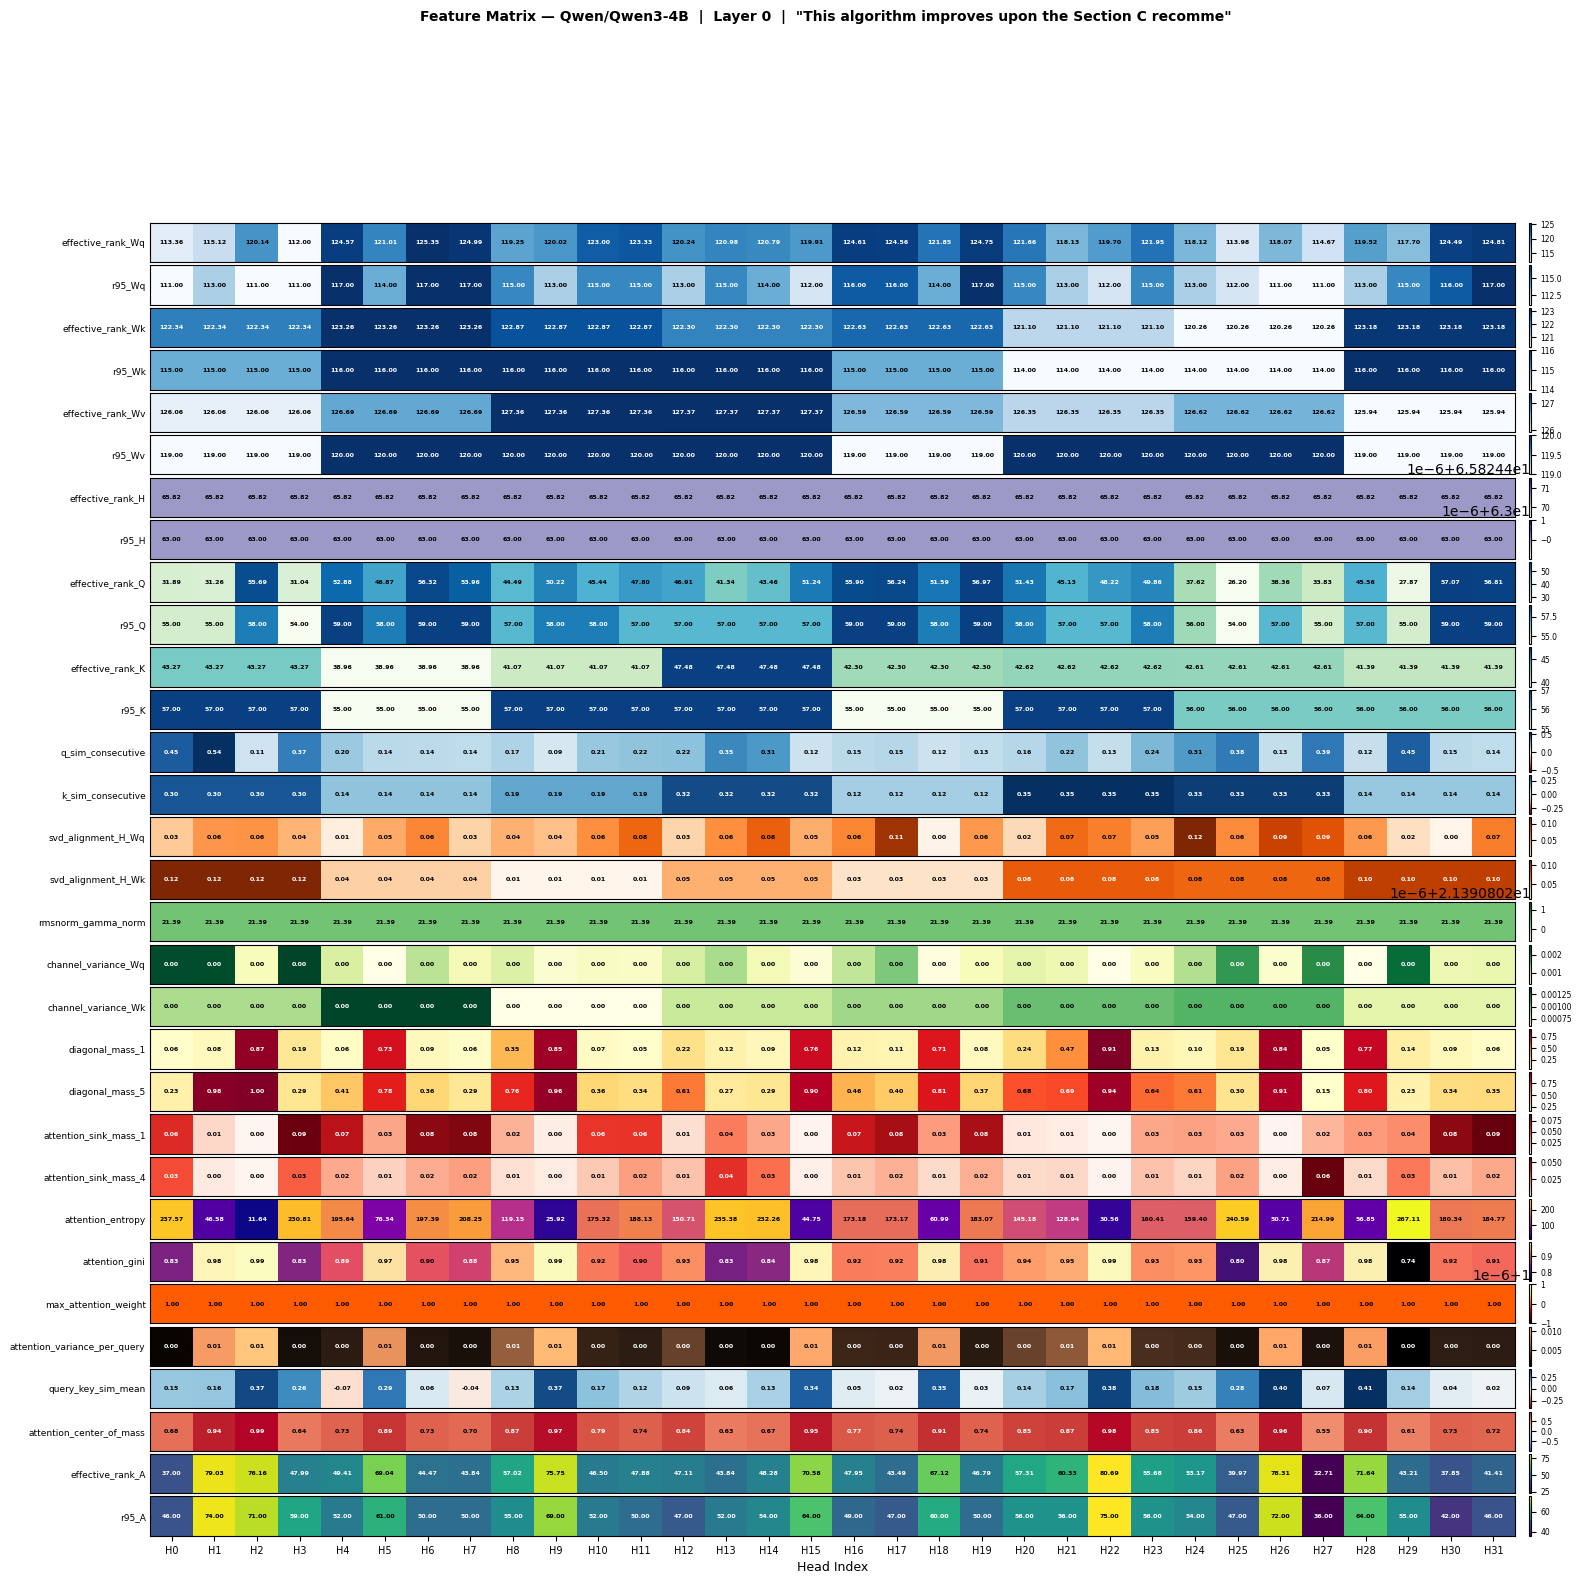

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# --- Mappa feature → colormap per gruppo semantico ---
FEATURE_CMAPS = {
    # Rank metriche (valori positivi, scala logaritmica) → sequenziale freddo
    "effective_rank_Wq":            "Blues",
    "r95_Wq":                       "Blues",
    "effective_rank_Wk":            "Blues",
    "r95_Wk":                       "Blues",
    "effective_rank_Wv":            "Blues",
    "r95_Wv":                       "Blues",
    # Hidden state rank → viola (distinto da W)
    "effective_rank_H":             "Purples",
    "r95_H":                        "Purples",
    # Q e K rank → ciano
    "effective_rank_Q":             "GnBu",
    "r95_Q":                        "GnBu",
    "effective_rank_K":             "GnBu",
    "r95_K":                        "GnBu",
    # Temporal similarity → divergente (valori in [-1, 1])
    "q_sim_consecutive":            "RdBu",
    "k_sim_consecutive":            "RdBu",
    "query_key_sim_mean":           "RdBu",
    # SVD alignment → arancio (valori in [0, 1])
    "svd_alignment_H_Wq":          "Oranges",
    "svd_alignment_H_Wk":          "Oranges",
    # RMSNorm e channel structure → verde
    "rmsnorm_gamma_norm":           "Greens",
    "channel_variance_Wq":          "YlGn",
    "channel_variance_Wk":          "YlGn",
    # Diagonal mass → calore (più massa = più locale)
    "diagonal_mass_1":              "YlOrRd",
    "diagonal_mass_5":              "YlOrRd",
    # Sink mass → rosso (più massa = più sink)
    "attention_sink_mass_1":        "Reds",
    "attention_sink_mass_4":        "Reds",
    # Entropy e sparsità → plasma
    "attention_entropy":            "plasma",
    "attention_gini":               "magma",
    "max_attention_weight":         "hot",
    "attention_variance_per_query": "copper",
    # Strutturale → coolwarm
    "attention_center_of_mass":     "coolwarm",
    # Rank di A → viridis
    "effective_rank_A":             "viridis",
    "r95_A":                        "viridis",
}

# Feature divergenti (centrate sullo zero per normalizzazione simmetrica)
DIVERGING_FEATURES = {"q_sim_consecutive", "k_sim_consecutive", "query_key_sim_mean",
                      "attention_center_of_mass"}

# --- Costruzione figura: una riga per feature, ognuna con la sua colormap ---
feature_cols = [c for c in df_layer0.columns if c not in ['model', 'prompt_id', 'layer', 'head']]
n_features   = len(feature_cols)
n_heads      = NUM_Q_HEADS

fig, axes = plt.subplots(
    nrows=n_features, ncols=1,
    figsize=(18, n_features * 0.55),
    gridspec_kw={"hspace": 0.08}
)

if n_features == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_cols):
    row_vals = df_layer0[feat].values.astype(float)  # shape: (n_heads,)
    data_2d  = row_vals[np.newaxis, :]               # shape: (1, n_heads)

    cmap = FEATURE_CMAPS.get(feat, "viridis")

    # Normalizzazione: divergente se la feature ha valori negativi attesi
    if feat in DIVERGING_FEATURES:
        vabs = np.nanmax(np.abs(row_vals))
        norm = mcolors.TwoSlopeNorm(vmin=-vabs, vcenter=0.0, vmax=vabs)
    else:
        vmin = np.nanmin(row_vals)
        vmax = np.nanmax(row_vals)
        # Evita norm degenere quando tutti i valori sono uguali
        if np.isclose(vmin, vmax):
            vmin = vmin - 1e-6
            vmax = vmax + 1e-6
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    im = ax.imshow(data_2d, aspect="auto", cmap=cmap, norm=norm)

    # Colorbar compatta a destra
    cbar = fig.colorbar(im, ax=ax, fraction=0.012, pad=0.01)
    cbar.ax.tick_params(labelsize=5.5)

    # Etichetta feature a sinistra
    ax.set_yticks([0])
    ax.set_yticklabels([feat], fontsize=6.5)
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    ax.tick_params(axis="y", length=0)

    # Valori numerici nelle celle (solo se la sequenza è corta)
    if n_heads <= 32:
        for h_idx, val in enumerate(row_vals):
            txt = f"{val:.2f}" if not np.isnan(val) else "nan"
            # Calcola luminanza del colore per scegliere testo chiaro/scuro
            rgba = plt.cm.get_cmap(cmap)(norm(val) if not np.isnan(val) else 0.5)
            lum  = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            txt_color = "white" if lum < 0.5 else "black"
            ax.text(h_idx, 0, txt, ha="center", va="center",
                    fontsize=4.5, color=txt_color, fontweight="bold")

# Asse X solo sull'ultima riga
axes[-1].tick_params(axis="x", bottom=True, labelbottom=True)
axes[-1].set_xticks(range(n_heads))
axes[-1].set_xticklabels([f"H{i}" for i in range(n_heads)], fontsize=7)
axes[-1].set_xlabel("Head Index", fontsize=9)

fig.suptitle(
    f"Feature Matrix — {MODEL_ID}  |  Layer {LAYER_IDX}  |  \"{PROMPT[:50]}\"",
    fontsize=10, y=1.005, fontweight="bold"
)

plt.savefig("layer0_features_multimap.png", dpi=160, bbox_inches="tight")
plt.show()